# 03 · Displacement map of a perovskite [110] image (complete pairs)

Data: `data/PZO11040nmHAADF.dm4`, a Dr. Probe multislice simulation of PbZrO₃
viewed along [110] (40 nm thick, HAADF, probe-convolved), from the VecMap
repository.

In the [110] projection the weaker B-containing column lies between two bright
Pb columns along the projected axis. Its reference position is the midpoint of
the two **measured** Pb columns of a complete pair.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import polarmap as pm
from polarmap import plotting

plt.rcParams["figure.dpi"] = 80
print("polarmap", pm.__version__)

polarmap 0.1.0


In [2]:
image, sampling = pm.load_image("data/PZO11040nmHAADF.dm4")
print(f"image {image.shape}, sampling {sampling:.5g} nm/px")

image (257, 294), sampling 0.016 nm/px


## 1. Detect all columns and split them by intensity

`min_distance` must now be smaller than the bright–weak separation, so that both
kinds of columns are found; the fitted amplitudes then separate them.

336 columns: 135 bright, 150 dim (amplitude threshold 0.2)


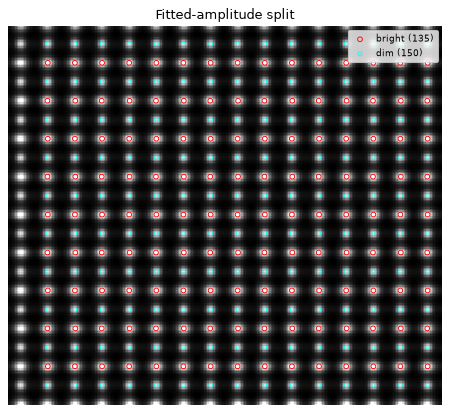

In [3]:
seeds = pm.detect_peaks(image, min_distance=8, threshold_rel=0.20)
split = pm.split_by_amplitude(image, seeds, box=3, edge=10)
print(f"{len(seeds)} columns: {len(split.bright)} bright, {len(split.dim)} dim "
      f"(amplitude threshold {split.threshold:.3g})")
plotting.plot_intensity_split(image, split);

## 2. Pair vector and complete pairs

`axis_hint=(0, 1)` means "the next bright column along the polar axis is below".

pair vector: [ 0.    25.701] px


120 complete pairs measured


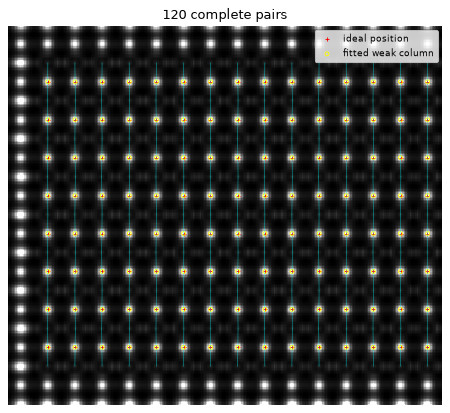

In [4]:
pair_vector = pm.estimate_pair_vector(split.bright, axis_hint=(0, 1))
print("pair vector:", np.round(pair_vector, 3), "px")
field = pm.measure_pair_displacement(image, split.bright, pair_vector)
print(f"{len(field)} complete pairs measured")
plotting.plot_pairs(field, split.bright);

## 3. Result

All displacements are horizontal and their sign alternates: an **antipolar**
arrangement, as expected for antiferroelectric PbZrO₃. The signed horizontal
component shows the pattern most clearly.

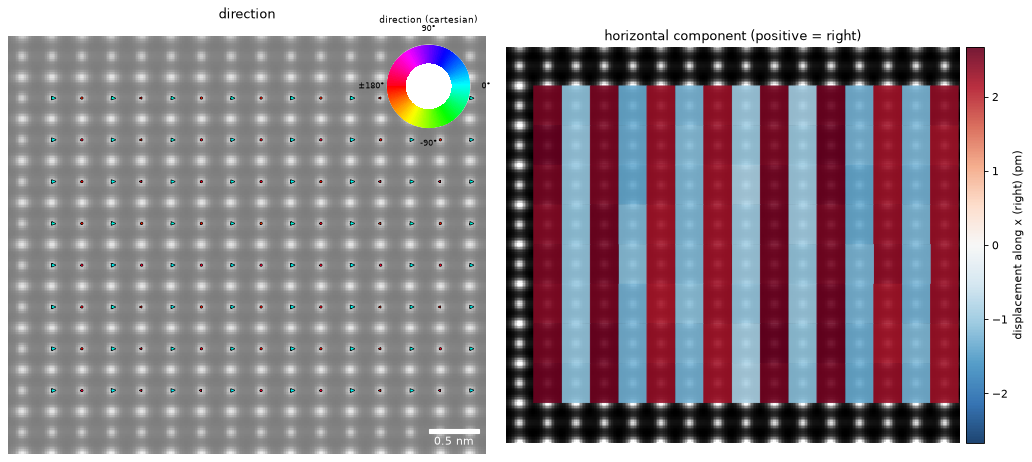

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plotting.plot_displacement_vectors(field, image, ax=axes[0], scale=15,
                                   sampling=sampling, scalebar_nm="auto",
                                   title="direction")
# The projected cell is strongly rectangular, so give the tile shape explicitly:
# the horizontal repeat of the bright columns and the pair vector.
row_vector = pm.estimate_pair_vector(split.bright, axis_hint=(1, 0))
plotting.plot_displacement_map(field, "u", ax=axes[1], image=image, sampling=sampling,
                               lattice_vectors=(row_vector, pair_vector),
                               title="horizontal component (positive = right)")
fig.tight_layout()

Displacement descriptors (n = 120, 0 excluded as outliers)
  magnitude |d| (pm): mean 1.8  median 2.2  std 0.7  MAD 0.4  min 0.9  max 2.7
  orientation (cartesian, deg): circular mean -1.2  circular std 132.8  (R = 0.07)


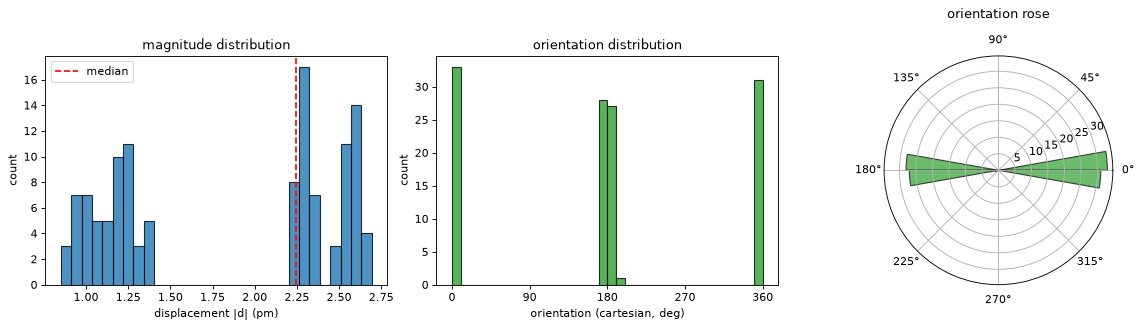

In [6]:
fig, axes, desc = plotting.plot_displacement_statistics(field, sampling)
print(pm.format_descriptors(desc))

The rose shows two opposite lobes (0° and 180°); the circular mean is
therefore meaningless here and the resultant length `R` is close to zero,
which is exactly what circular statistics are designed to reveal.